In [1]:
import numpy as np
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import CXGate, RXGate, XGate
from qiskit.quantum_info import Operator, Pauli, process_fidelity

## Convert classes to Operator


In [2]:
# Create an Operator from a Pauli object

pauliXX = Pauli("XX")
Operator(pauliXX)

Operator([[0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
          [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
          [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
          [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


In [3]:
# Create an Operator for a Gate object
Operator(CXGate())

Operator([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
          [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
          [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


Just initialize the Operator class to convert the object to an Operator.

In [4]:
# Create an operator from a parameterized Gate object
Operator(RXGate(np.pi / 2))

Operator([[0.70710678+0.j        , 0.        -0.70710678j],
          [0.        -0.70710678j, 0.70710678+0.j        ]],
         input_dims=(2,), output_dims=(2,))


In [5]:
# Create an operator from a QuantumCircuit object
circ = QuantumCircuit(10)
circ.h(0)
for j in range(1, 10):
    circ.cx(j - 1, j)

# Convert circuit to an operator by implicit unitary simulation
Operator(circ)

Operator([[ 0.70710678+0.j,  0.70710678+0.j,  0.        +0.j, ...,
            0.        +0.j,  0.        +0.j,  0.        +0.j],
          [ 0.        +0.j,  0.        +0.j,  0.70710678+0.j, ...,
            0.        +0.j,  0.        +0.j,  0.        +0.j],
          [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
            0.        +0.j,  0.        +0.j,  0.        +0.j],
          ...,
          [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
            0.        +0.j,  0.        +0.j,  0.        +0.j],
          [ 0.        +0.j,  0.        +0.j,  0.70710678+0.j, ...,
            0.        +0.j,  0.        +0.j,  0.        +0.j],
          [ 0.70710678+0.j, -0.70710678+0.j,  0.        +0.j, ...,
            0.        +0.j,  0.        +0.j,  0.        +0.j]],
         input_dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2), output_dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2))


Let's see what happens if we insert an unsupported operation like a measurement in the circuit.

In [6]:
# Create an operator from a QuantumCircuit object
circ = QuantumCircuit(10)
circ.h(0)
for j in range(1, 10):
    circ.cx(j - 1, j)
circ.measure_all()

# Convert circuit to an operator by implicit unitary simulation
Operator(circ)

QiskitError: 'Cannot apply operation with classical bits: measure'

In [7]:
# Create an operator from a QuantumCircuit object
circ = QuantumCircuit(10)
circ.h(0)
for j in range(1, 10):
    circ.cx(j - 1, j)
circ.reset(0)


# Convert circuit to an operator by implicit unitary simulation
Operator(circ)

QiskitError: 'Cannot apply Operation: reset'

## Use Operators in circuits

Unitary Operators can be directly inserted into a QuantumCircuit using the QuantumCircuit.append method. This converts the Operator into a UnitaryGate object, which is added to the circuit.

If the operator is not unitary, an exception is raised. This can be checked using the Operator.is_unitary() function, which returns True if the operator is unitary and False otherwise.

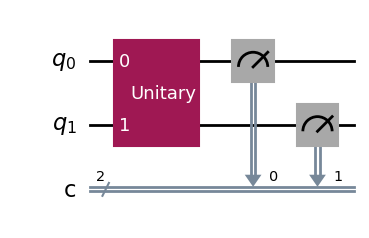

In [7]:
# Create an operator
XX = Operator(Pauli("XX"))

# Add to a circuit
circ = QuantumCircuit(2, 2)
circ.append(XX, [0, 1])
circ.measure([0, 1], [0, 1])
circ.draw("mpl")

In [9]:
# Add to a circuit directly from Pauli class also
circ2 = QuantumCircuit(2, 2)
circ2.append(Pauli("XX"), [0, 1])
circ2.measure([0, 1], [0, 1])
circ2.draw()

┌────────────┐┌─┐   
q_0: ┤0           ├┤M├───
     │  Pauli(XX) │└╥┘┌─┐
q_1: ┤1           ├─╫─┤M├
     └────────────┘ ║ └╥┘
c: 2/═══════════════╩══╩═
                    0  1

Let's see what happens if we try to add a non-unitary operator to a circuit.

In [18]:
non_unitary_mat = np.array(
    [[1, 0],
    [0, 0]])
non_unitary_op = Operator(non_unitary_mat)
print(non_unitary_op)

Operator([[1.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j]],
         input_dims=(2,), output_dims=(2,))


In [19]:
non_unitary_op.is_unitary()

False

In [20]:
circ = QuantumCircuit(1, 1)
circ.append(non_unitary_op, [0])


ValueError: Input matrix is not unitary.

## Combine Operators

### Tensor product

In [8]:
# It makes A⊗B
A = Operator(Pauli("X"))
B = Operator(Pauli("Z"))
A.tensor(B)   # B is applied on qubit 0 and A is applied on qubit 1

Operator([[ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
          [ 0.+0.j, -0.+0.j,  0.+0.j, -1.+0.j],
          [ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
          [ 0.+0.j, -1.+0.j,  0.+0.j, -0.+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


### Tensor expansion

In [9]:
# It makes B⊗A
A = Operator(Pauli("X"))
B = Operator(Pauli("Z"))
A.expand(B)

Operator([[ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j],
          [ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
          [ 0.+0.j,  0.+0.j, -0.+0.j, -1.+0.j],
          [ 0.+0.j,  0.+0.j, -1.+0.j, -0.+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


### Composition

In [10]:
# makes BA
A = Operator(Pauli("X"))
B = Operator(Pauli("Z"))
A.compose(B)

Operator([[ 0.+0.j,  1.+0.j],
          [-1.+0.j,  0.+0.j]],
         input_dims=(2,), output_dims=(2,))


In [11]:
# makes AB
A = Operator(Pauli("X"))
B = Operator(Pauli("Z"))
A.compose(B, front=True)

Operator([[ 0.+0.j, -1.+0.j],
          [ 1.+0.j,  0.+0.j]],
         input_dims=(2,), output_dims=(2,))


Requires that the total output dimension of the first operator
A is equal to the total input dimension of the composed operator
B (and similarly, the output dimension of
B must be equal to the input dimension of
A when composing with front=True).

### Subsystem composition

Compose a smaller operator with a selection of subsystems on a larger operator using the qargs kwarg of compose, either with or without front=True. In this case, the relevant input and output dimensions of the subsystems being composed must match. Note that the smaller operator must always be the argument of the compose method.

For example, to compose a two-qubit gate with a three-qubit operator:

In [12]:
# Compose XZ with a 3-qubit identity operator
op = Operator(np.eye(2**3))
XZ = Operator(Pauli("XZ"))
op.compose(XZ, qargs=[0, 2])

Operator([[ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
           -1.+0.j],
          [ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j]],
         input_dims=(2, 2, 2), output_dims=(2, 2, 2))


In [13]:
# Compose YX in front of the previous operator
op = Operator(np.eye(2**3))
YX = Operator(Pauli("YX"))
op.compose(YX, qargs=[0, 2], front=True)

Operator([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.-1.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.-1.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.-1.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.-1.j, 0.+0.j],
          [0.+0.j, 0.+1.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+1.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 0.+1.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+1.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]],
         input_dims=(2, 2, 2), output_dims=(2, 2, 2))


### Linear combinations

In [14]:
XX = Operator(Pauli("XX"))
YY = Operator(Pauli("YY"))
ZZ = Operator(Pauli("ZZ"))

op = 0.5 * (XX + YY - 3 * ZZ)
op

Operator([[-1.5+0.j,  0. +0.j,  0. +0.j,  0. +0.j],
          [ 0. +0.j,  1.5+0.j,  1. +0.j,  0. +0.j],
          [ 0. +0.j,  1. +0.j,  1.5+0.j,  0. +0.j],
          [ 0. +0.j,  0. +0.j,  0. +0.j, -1.5+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


While tensor, expand, and compose preserves the unitarity of unitary operators, linear combinations do not; hence, adding two unitary operators will, in general, result in a non-unitary operator:

In [15]:
op.is_unitary()

False

### Implicit conversion to Operator

In [16]:
# Compose with a matrix passed as a list
Operator(np.eye(2)).compose([[0, 1], [1, 0]])

Operator([[0.+0.j, 1.+0.j],
          [1.+0.j, 0.+0.j]],
         input_dims=(2,), output_dims=(2,))


In [17]:
# Compose with a matrix passed as a list
Operator(np.eye(2)).compose([[0, 0], [1, 0]])

Operator([[0.+0.j, 0.+0.j],
          [1.+0.j, 0.+0.j]],
         input_dims=(2,), output_dims=(2,))


## Compare Operators

Operators implement an equality method that can be used to check if two operators are approximately equal.

In [22]:
Operator(Pauli("X")) == Operator(XGate())

True

Note that this checks that each matrix element of the operators is approximately equal; two unitaries that differ by a global phase are not considered equal:

In [23]:
Operator(XGate()) == np.exp(1j * 0.5) * Operator(XGate())

False

### Process fidelity

In [24]:
# Two operators which differ only by phase
op_a = Operator(XGate())
op_b = np.exp(1j * 0.5) * Operator(XGate())

# Compute process fidelity
F = process_fidelity(op_a, op_b)
print("Process fidelity =", F)

Process fidelity = 1.0


This quantity does not depend on the global phase. Note that process fidelity is generally only a valid measure of closeness if the input operators are unitary.